In [1]:
%cd ../..
%load_ext autoreload
%autoreload 2

/nfs/scistore19/locatgrp/rcadei/artificial-causal-inference


# PPCI — Ants

Prediction-Powered Causal Inference on the ants grooming dataset.

## 0. Imports & config

In [2]:
SUBJECT = "ants"
ENCODER = "dinov2"
TOKEN   = "class"

In [3]:
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from scipy.stats import mannwhitneyu, sem, t as t_dist

from src.ppci import (
    PPCIDataset, build_model, train, compute_metrics,
    compute_teb_all_pairs,
    plot_outcome_distribution_ants, plot_summary, plot_comparison,
)

cfg    = OmegaConf.load(f"configs/ppci/{SUBJECT}/config.yaml")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_ds_kwargs = dict(
    outcome_cols=list(cfg.outcome.columns),
    task=cfg.outcome.task,
    env_cols=list(cfg.causal.confounders),
    env_include_treatment=True,
    n_val_videos=cfg.validation.n_videos,
    seed=cfg.training.seed,
)
outcomes = [c[len("Y_"):] for c in cfg.outcome.columns]

## 1. Dataset summary

Load a PPCIDataset from disk and inspect frame counts, treatment distribution, and outcome label balance.

In [4]:
ANNOTATED_VERSIONS = ["v1","v2","v3","v4"]

datasets = {}
for v in ANNOTATED_VERSIONS:
    datasets[v] = PPCIDataset.from_disk(SUBJECT, v, ENCODER, TOKEN, **_ds_kwargs)
    #print(datasets[v])

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v1/hf


Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

/nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/src/ppci/dataset.py:480: UserWarning: [PPCIDataset] Environment columns not found in dataset (skipped): ['W_nestbox', 'W_weak_marking']. Available W_* columns: ['W_annotator', 'W_batch', 'W_position', 'W_recording_date', 'W_recording_hour']
  return cls(hf, emb, **kwargs)


Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v2/hf


/nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/src/ppci/dataset.py:480: UserWarning: [PPCIDataset] Environment columns not found in dataset (skipped): ['W_nestbox', 'W_weak_marking']. Available W_* columns: ['W_annotator', 'W_annotator_order', 'W_batch', 'W_position', 'W_recording_date', 'W_recording_hour']
  return cls(hf, emb, **kwargs)


Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v3/hf


Loading dataset from disk:   0%|          | 0/25 [00:00<?, ?it/s]

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v4/hf


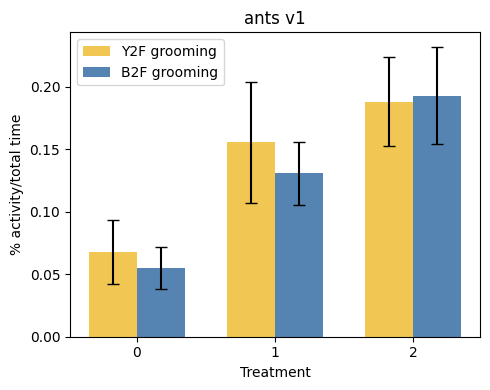

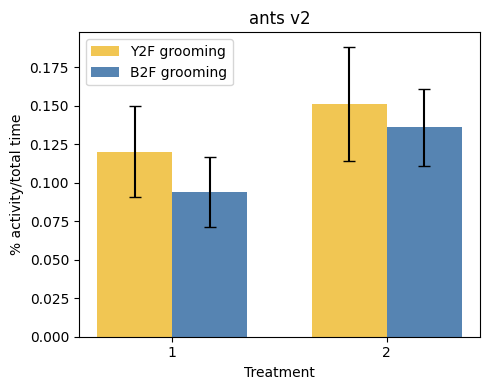

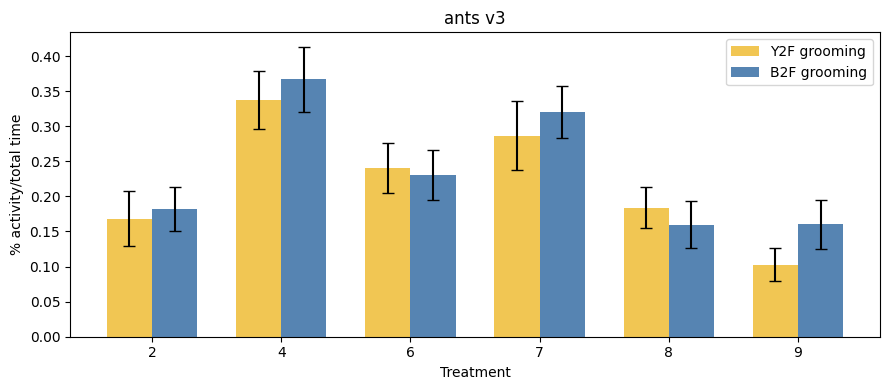

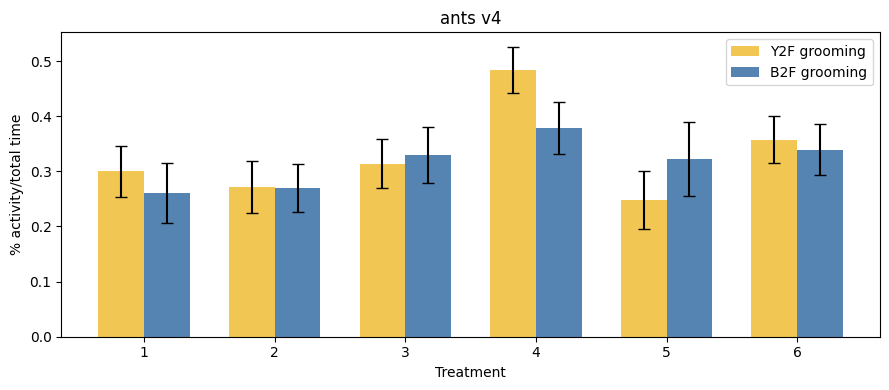

In [5]:
for ds in datasets.values():
    plot_outcome_distribution_ants(ds)

In [6]:
obs_v3 = datasets["v3"].obs_level()
obs_v4 = datasets["v4"].obs_level()

shared_treatments = set(obs_v3["T"].tolist()).intersection(set(obs_v4["T"].tolist()))
print(f"Shared treatments between v3 and v4: {sorted(shared_treatments)}")

def mean_ci(x, confidence=0.95):
    ci = t_dist.interval(confidence, df=len(x) - 1, loc=x.mean(), scale=sem(x))
    return x.mean(), ci[0], ci[1]

for treatment in sorted(shared_treatments):
    y3 = obs_v3.loc[obs_v3["T"] == treatment, "Y_avg"].values
    y4 = obs_v4.loc[obs_v4["T"] == treatment, "Y_avg"].values

    m3, lo3, hi3 = mean_ci(y3)
    m4, lo4, hi4 = mean_ci(y4)
    stat, p_value = mannwhitneyu(y3, y4, alternative="two-sided")

    print(f"Treatment: {treatment}  (n v3={len(y3)}, n v4={len(y4)})")
    print(f"  APO v3: {m3:.4f} [{lo3:.4f}, {hi3:.4f}]")
    print(f"  APO v4: {m4:.4f} [{lo4:.4f}, {hi4:.4f}]")
    print(f"  Mann-Whitney U: {stat:.1f}, p-value: {float(p_value):.4f}")
    print("-" * 50)

Shared treatments between v3 and v4: ['2', '4', '6']
Treatment: 2  (n v3=38, n v4=20)
  APO v3: 0.1749 [0.1140, 0.2358]
  APO v4: 0.2708 [0.1967, 0.3449]
  Mann-Whitney U: 237.5, p-value: 0.0199
--------------------------------------------------
Treatment: 4  (n v3=33, n v4=19)
  APO v3: 0.3522 [0.2764, 0.4280]
  APO v4: 0.4314 [0.3499, 0.5129]
  Mann-Whitney U: 233.0, p-value: 0.1285
--------------------------------------------------
Treatment: 6  (n v3=34, n v4=20)
  APO v3: 0.2355 [0.1757, 0.2953]
  APO v4: 0.3483 [0.2690, 0.4276]
  Mann-Whitney U: 209.0, p-value: 0.0194
--------------------------------------------------


## 2. Single train

- Training set: `ants/v3` 

- Test set: `ants/v4`

In [7]:
torch.manual_seed(cfg.training.seed)
ds_train, ds_test = datasets["v3"], datasets["v4"]
best_model = train(ds_train, build_model(ds_train, cfg), cfg).to(device)

Epoch   1  train_loss=0.415  train_acc=0.860~  train_bacc=0.767~  train_recall=0.600~  train_precision=0.722~  val_acc=0.842  val_bacc=0.768  val_recall=0.630  val_precision=0.629
Epoch   2  train_loss=0.343  train_acc=0.871~  train_bacc=0.761~  train_recall=0.563~  train_precision=0.801~  val_acc=0.844  val_bacc=0.734  val_recall=0.532  val_precision=0.690
Epoch   3  train_loss=0.331  train_acc=0.889~  train_bacc=0.815~  train_recall=0.682~  train_precision=0.790~  val_acc=0.858  val_bacc=0.757  val_recall=0.581  val_precision=0.673
Epoch   4  train_loss=0.310  train_acc=0.890~  train_bacc=0.787~  train_recall=0.602~  train_precision=0.857~  val_acc=0.847  val_bacc=0.703  val_recall=0.453  val_precision=0.713
Epoch   5  train_loss=0.299  train_acc=0.905~  train_bacc=0.836~  train_recall=0.713~  train_precision=0.832~  val_acc=0.856  val_bacc=0.755  val_recall=0.575  val_precision=0.689
Epoch   6  train_loss=0.291  train_acc=0.913~  train_bacc=0.859~  train_recall=0.762~  train_precisi

**Eval**: In-distribution

train — acc=0.944  bacc=0.919  recall=0.874  precision=0.879
val   — acc=0.867  bacc=0.789  recall=0.652  precision=0.692


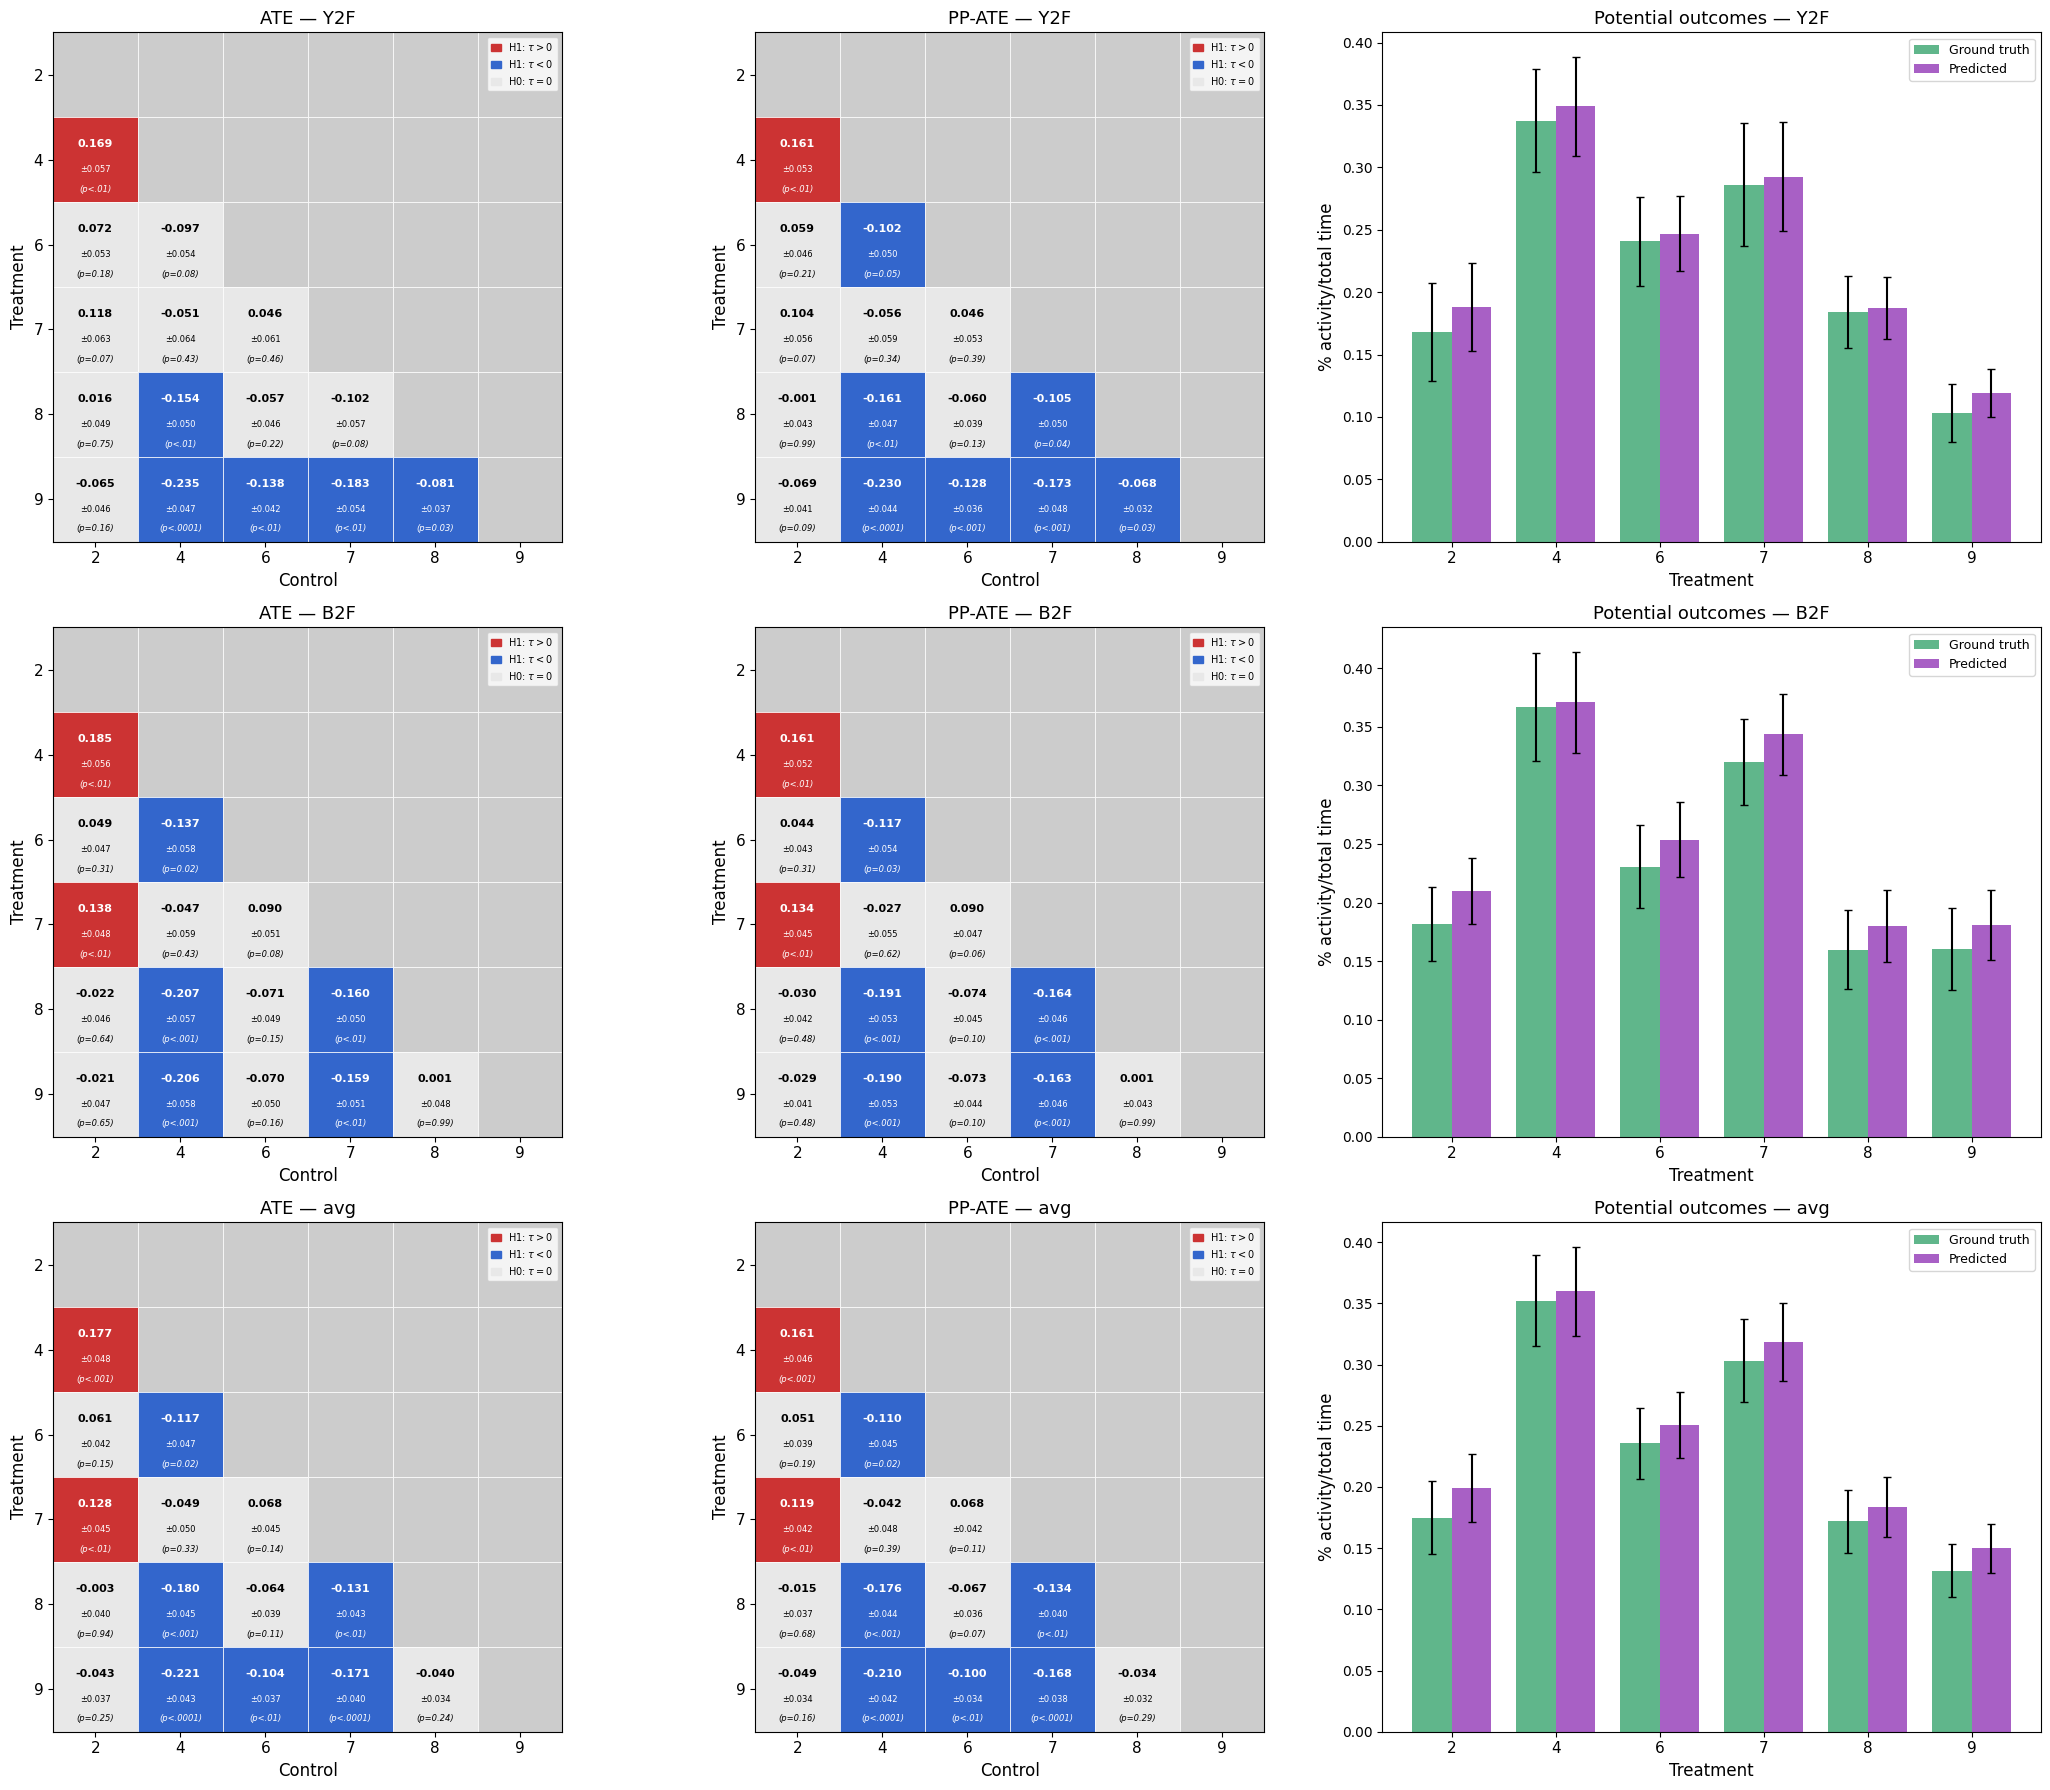

In [8]:
m_train = compute_metrics(best_model, ds_train.X_train, ds_train.Y_train, device)
m_val   = compute_metrics(best_model, ds_train.X_val,   ds_train.Y_val,   device)
print(f"train — acc={m_train['acc']:.3f}  bacc={m_train['bacc']:.3f}  recall={m_train['recall']:.3f}  precision={m_train['precision']:.3f}")
print(f"val   — acc={m_val['acc']:.3f}  bacc={m_val['bacc']:.3f}  recall={m_val['recall']:.3f}  precision={m_val['precision']:.3f}")
plot_summary(ds_train.add_predictions(best_model, device).obs_level(), outcomes, annotations=True)

**Eval:** Out-of-distribution

test  — acc=0.762  bacc=0.753  recall=0.726  precision=0.612


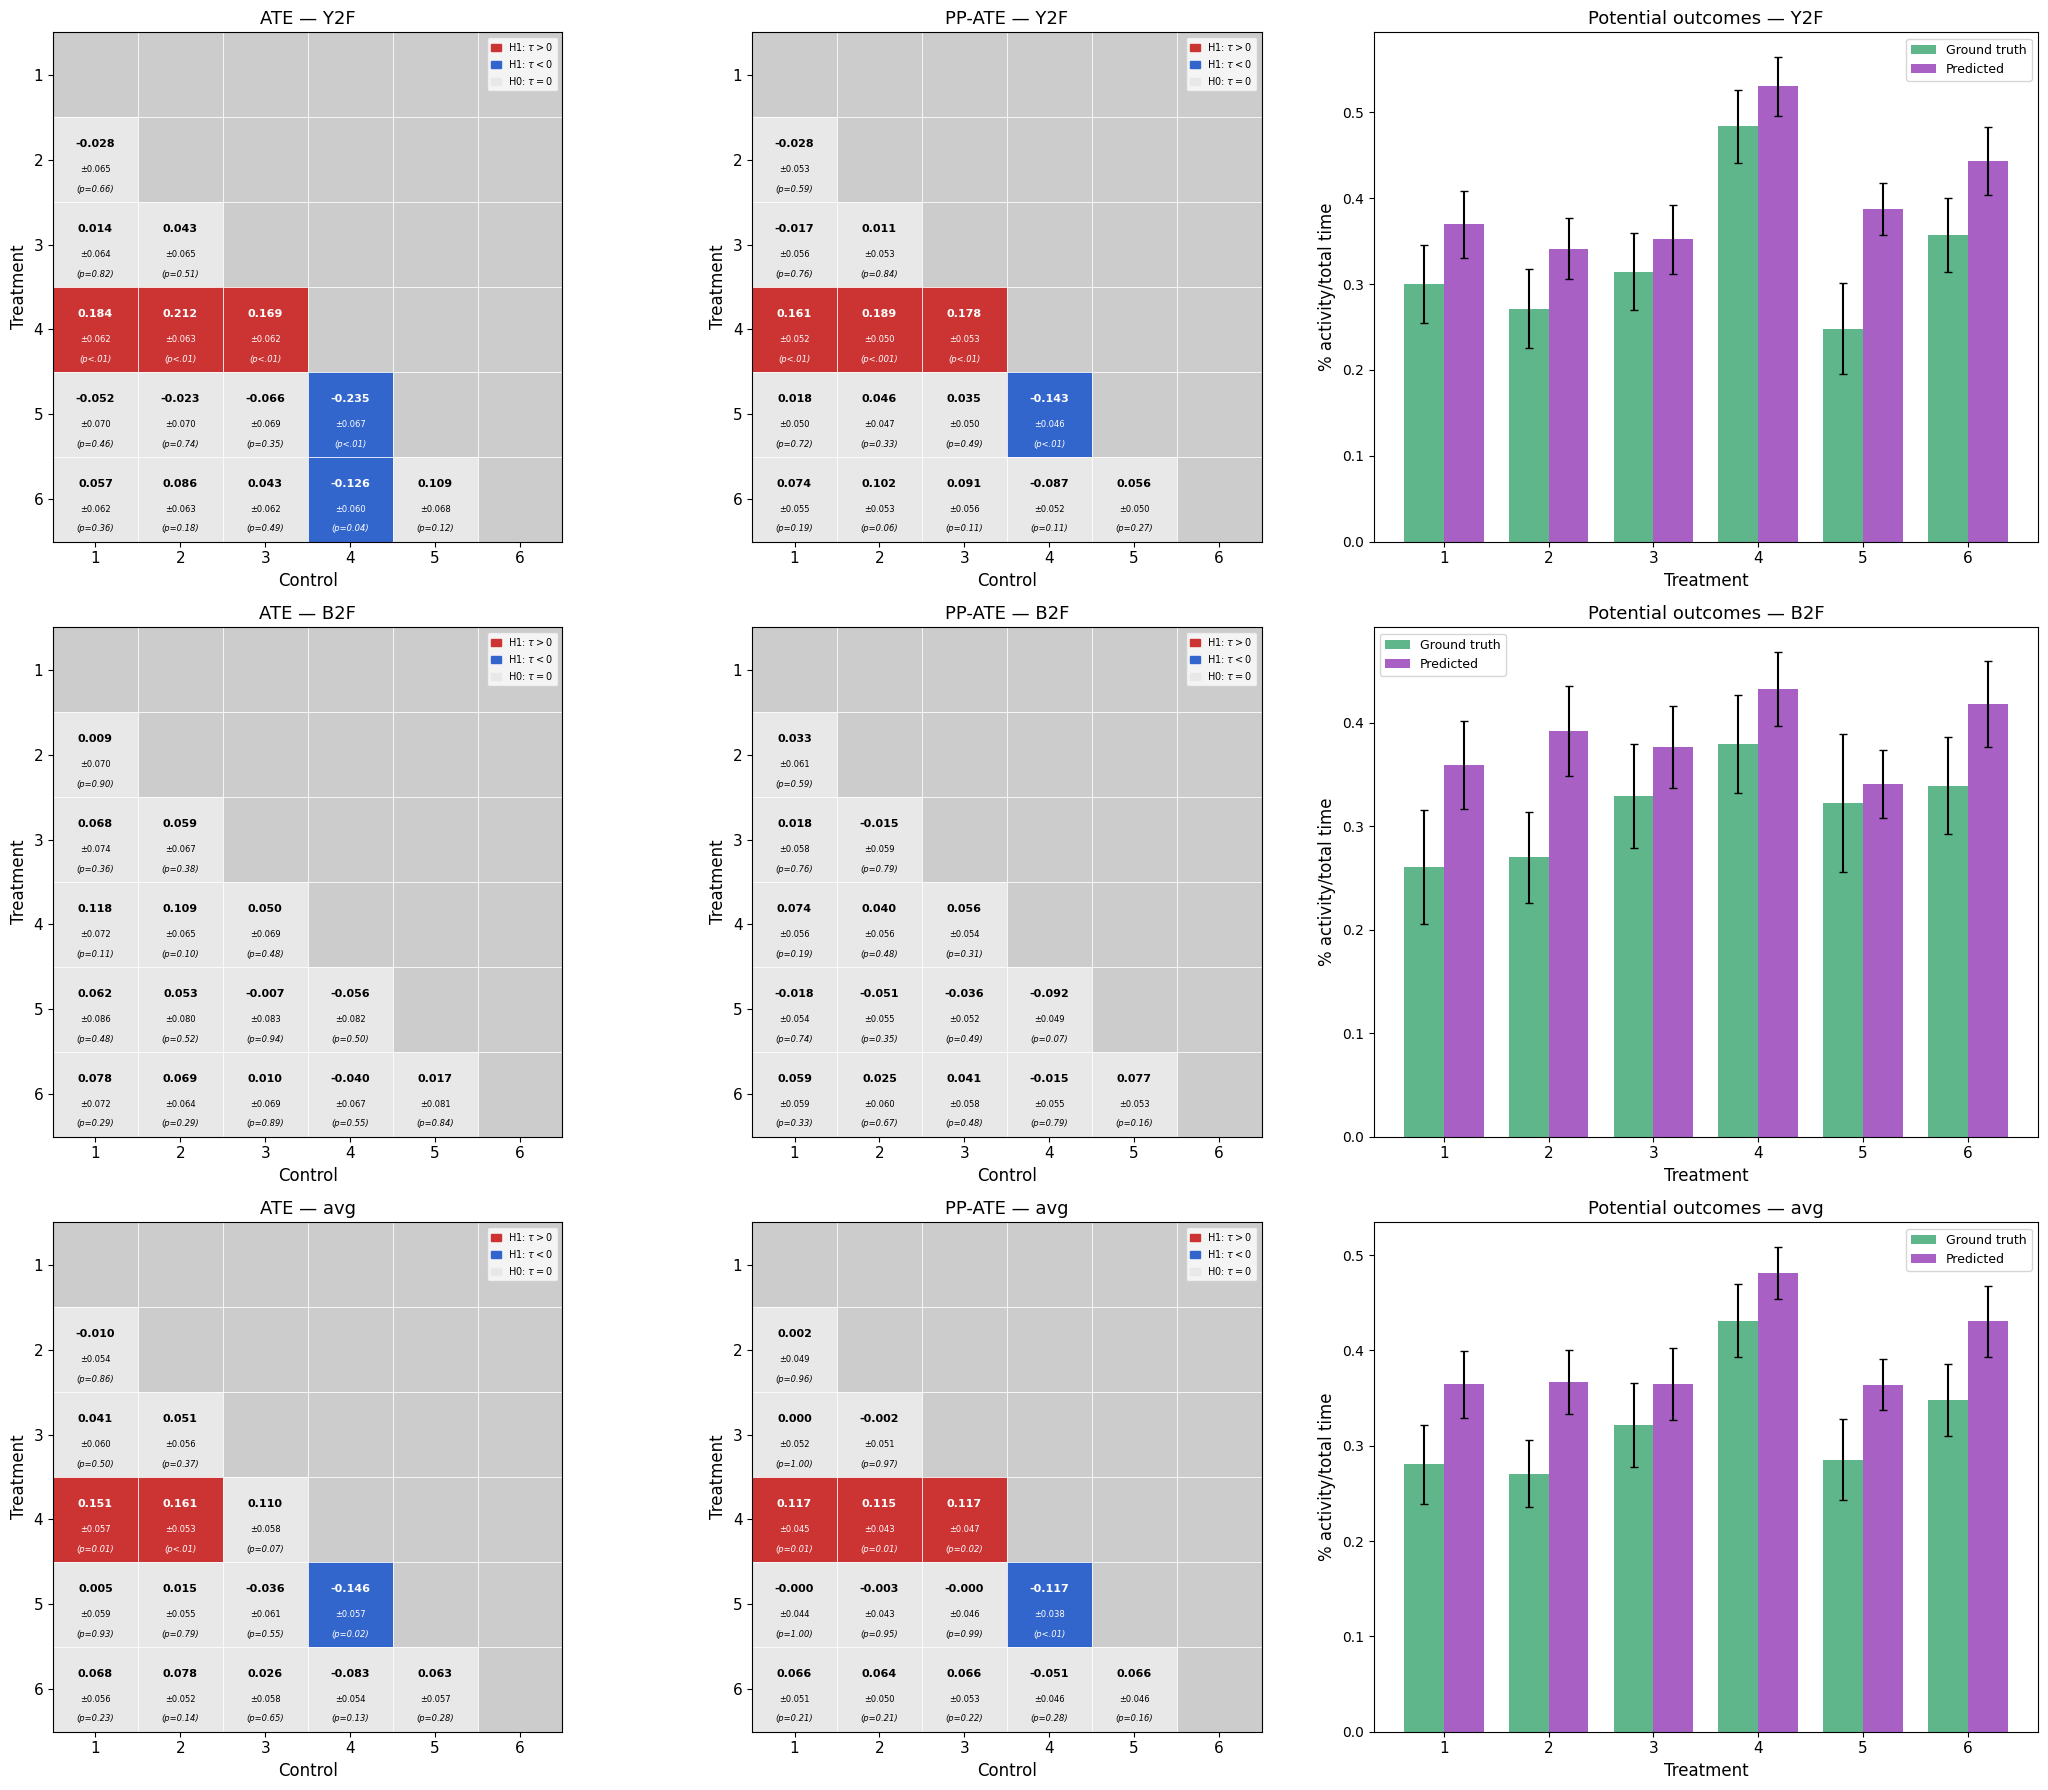

In [9]:
m_test = compute_metrics(best_model, ds_test.X, ds_test.Y, device)
print(f"test  — acc={m_test['acc']:.3f}  bacc={m_test['bacc']:.3f}  recall={m_test['recall']:.3f}  precision={m_test['precision']:.3f}")
plot_summary(ds_test.add_predictions(best_model, device).obs_level(), outcomes)

## 3. Compare methods

Vary training routine: ERM, DERM, vREx, IRM

- Training set: `ants/v3`

- Test set: `ants/v4`

In [10]:
METHODS = ["ERM", "vREx", "IRM", "DERM"]

results_val, results_test = {}, {}
for method in METHODS:
    print(f"\n── {method} ──")
    m_cfg = OmegaConf.merge(cfg, OmegaConf.create({"training": {"method": method, "seed": 0}}))
    torch.manual_seed(0)
    best = train(ds_train, build_model(ds_train, m_cfg), m_cfg).to(device)
    m_val  = compute_metrics(best, ds_train.X_val, ds_train.Y_val, device)
    m_test = compute_metrics(best, ds_test.X, ds_test.Y, device)
    _, summary_train = compute_teb_all_pairs(best, ds_train, device, method="aipw")
    _, summary_test  = compute_teb_all_pairs(best, ds_test,  device, method="aipw")
    results_val[method]  = {"acc": m_val["acc"],  "precision": m_val["precision"],
                             "recall": m_val["recall"],  "summary_df": summary_train}
    results_test[method] = {"acc": m_test["acc"], "precision": m_test["precision"],
                             "recall": m_test["recall"], "summary_df": summary_test}


── ERM ──
Epoch   1  train_loss=0.420  train_acc=0.858~  train_bacc=0.733~  train_recall=0.510~  train_precision=0.769~  val_acc=0.846  val_bacc=0.737  val_recall=0.538  val_precision=0.674
Epoch   2  train_loss=0.344  train_acc=0.872~  train_bacc=0.771~  train_recall=0.589~  train_precision=0.788~  val_acc=0.838  val_bacc=0.729  val_recall=0.527  val_precision=0.677
Epoch   3  train_loss=0.326  train_acc=0.889~  train_bacc=0.822~  train_recall=0.700~  train_precision=0.779~  val_acc=0.859  val_bacc=0.763  val_recall=0.595  val_precision=0.676
Epoch   4  train_loss=0.312  train_acc=0.890~  train_bacc=0.791~  train_recall=0.614~  train_precision=0.850~  val_acc=0.841  val_bacc=0.697  val_recall=0.445  val_precision=0.696
Epoch   5  train_loss=0.294  train_acc=0.902~  train_bacc=0.824~  train_recall=0.685~  train_precision=0.846~  val_acc=0.850  val_bacc=0.733  val_recall=0.526  val_precision=0.698
Epoch   6  train_loss=0.282  train_acc=0.913~  train_bacc=0.851~  train_recall=0.740~  tr

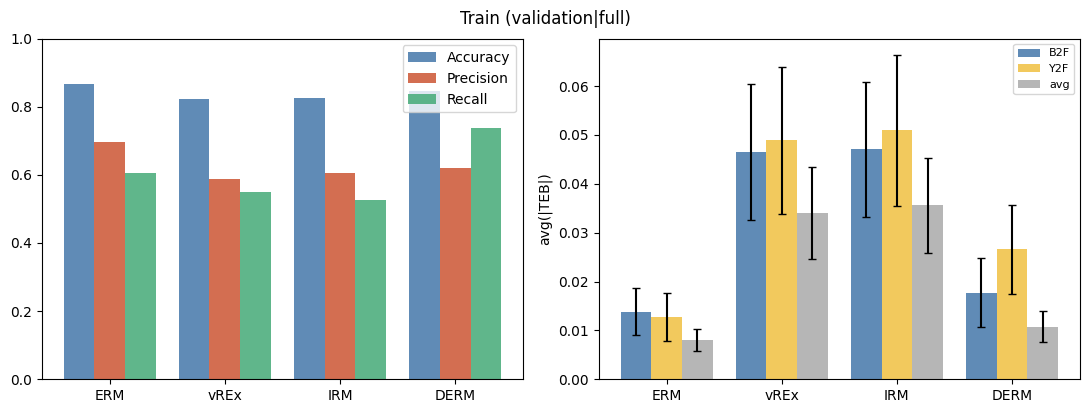

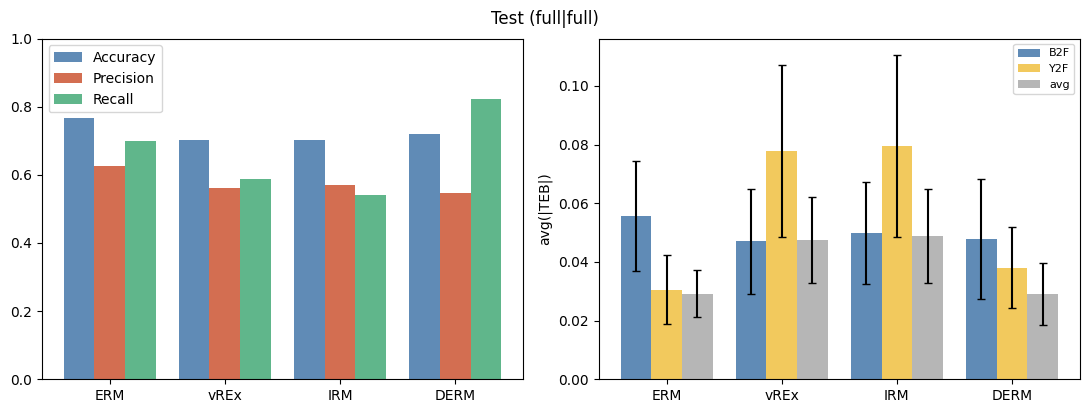

In [11]:
fig = plot_comparison(results_val)
fig.suptitle("Train (validation|full)", y=1.02)
plt.show()

fig = plot_comparison(results_test)
fig.suptitle("Test (full|full)", y=1.02)
plt.show()

## 4. Deployment

Deployment model and new evaluation.

- Training set: `ants/v3` + `ants/v4`

- Test set: `ants/v5`

In [12]:
# For deployment: reload train datasets with n_val_videos=0 to include all data in training
_deploy_kwargs = {**_ds_kwargs, "n_val_videos": 0}
ds_train   = PPCIDataset.concat([PPCIDataset.from_disk(SUBJECT, "v3", ENCODER, TOKEN, **_deploy_kwargs), 
                                 PPCIDataset.from_disk(SUBJECT, "v4", ENCODER, TOKEN, **_deploy_kwargs)])
ds_test    = PPCIDataset.from_disk(SUBJECT, "v5", ENCODER, TOKEN, **{**_ds_kwargs, "n_val_videos": 0})
print(ds_train)
print(ds_test)

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v3/hf


Loading dataset from disk:   0%|          | 0/25 [00:00<?, ?it/s]

Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v4/hf
Loading pre-generated HF dataset from /nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/dataset/ants/v5/hf


Loading dataset from disk:   0%|          | 0/33 [00:00<?, ?it/s]

/nfs/scistore19/locatgrp/rcadei/artificial-causal-inference/src/ppci/dataset.py:480: UserWarning: [PPCIDataset] Environment columns not found in dataset (skipped): ['W_annotator']. Available W_* columns: ['W_batch', 'W_nestbox', 'W_position', 'W_recording_date', 'W_recording_hour', 'W_weak_marking']
  return cls(hf, emb, **kwargs)


PPCIDataset summary:
  name            : ants v3 + ants v4
  total frames    : 975,000  (train=975,000, val=0)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
  obs per treatment: [20, 58, 20, 52, 14, 54, 34, 35, 38]
  env columns     : ['W_nestbox', 'W_batch', 'W_annotator', 'W_weak_marking', 'T']
  n_envs (train)  : 207
  val videos      : []
PPCIDataset summary:
  name            : ants v5
  total frames    : 681,000  (train=681,000, val=0)
  embedding dim   : 768
  task            : multilabel
  outcome columns : ['Y_Y2F', 'Y_B2F']
  treatment values: ['A', 'B', 'C', 'D', 'E', 'F']
  obs per treatment: [42, 38, 35, 38, 36, 38]
  env columns     : ['W_nestbox', 'W_batch', 'W_weak_marking', 'T']
  n_envs (train)  : 95
  val videos      : []


In [13]:
torch.manual_seed(cfg.training.seed)
best_multi = train(ds_train, build_model(ds_train, cfg), cfg).to(device)

Epoch   1  train_loss=0.442  train_acc=0.837~  train_bacc=0.735~  train_recall=0.527~  train_precision=0.765~
Epoch   2  train_loss=0.380  train_acc=0.854~  train_bacc=0.775~  train_recall=0.614~  train_precision=0.769~
Epoch   3  train_loss=0.362  train_acc=0.861~  train_bacc=0.770~  train_recall=0.584~  train_precision=0.821~
Epoch   4  train_loss=0.347  train_acc=0.877~  train_bacc=0.813~  train_recall=0.682~  train_precision=0.809~
Epoch   5  train_loss=0.334  train_acc=0.889~  train_bacc=0.843~  train_recall=0.751~  train_precision=0.802~
Epoch   6  train_loss=0.322  train_acc=0.894~  train_bacc=0.843~  train_recall=0.739~  train_precision=0.830~
Epoch   7  train_loss=0.316  train_acc=0.898~  train_bacc=0.833~  train_recall=0.699~  train_precision=0.879~
Epoch   8  train_loss=0.295  train_acc=0.906~  train_bacc=0.882~  train_recall=0.832~  train_precision=0.814~
Epoch   9  train_loss=0.298  train_acc=0.907~  train_bacc=0.849~  train_recall=0.730~  train_precision=0.889~
Epoch  10 

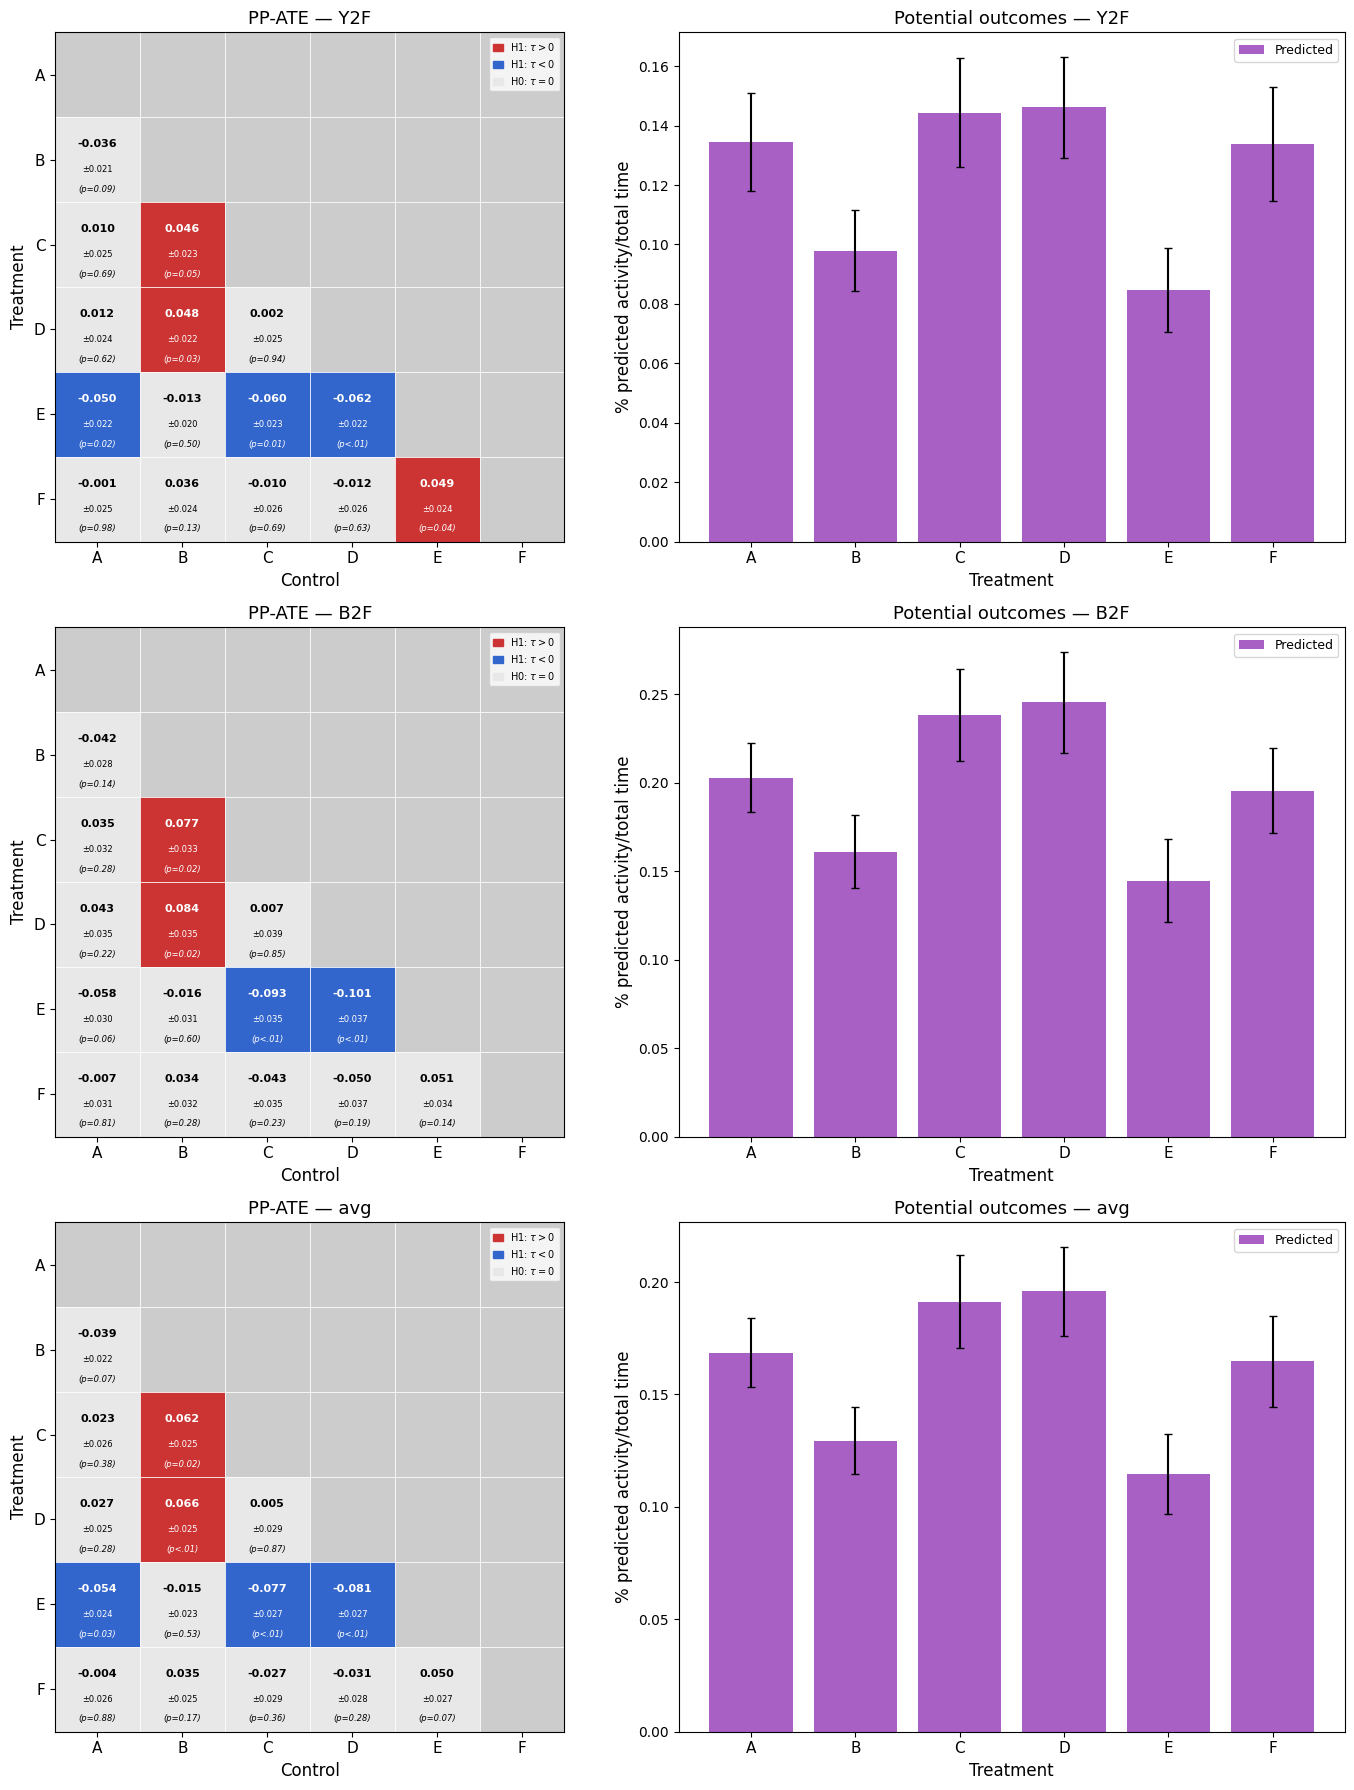

In [14]:
plot_summary(ds_test.add_predictions(best_multi, device).obs_level(), outcomes)